# Fidelity Benchmark — Visualisation
Generates publication-ready figures from `benchmarks/results/fidelity.json`.

In [13]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

In [14]:
# Load results
with open('results/fidelity.json', 'r') as f:
    data = json.load(f)

os.makedirs('figures', exist_ok=True)

ideal = data['ideal_results']
noisy = data['noisy_results']
ideal_summary = data['ideal_summary']
noisy_summary = data['noisy_summary']

print(f"Ideal trials: {len(ideal)}")
print(f"Noisy trials: {len(noisy)}")
print(f"Ideal summary: {ideal_summary}")

Ideal trials: 800
Noisy trials: 400
Ideal summary: [{'n_clones': 2, 'trials': 200, 'mean_fidelity': 0.9999999999999997, 'min_fidelity': 0.9999999999999991, 'max_deviation': 8.881784197001252e-16}, {'n_clones': 3, 'trials': 200, 'mean_fidelity': 0.9999999999999997, 'min_fidelity': 0.999999999999999, 'max_deviation': 9.992007221626409e-16}, {'n_clones': 4, 'trials': 200, 'mean_fidelity': 0.9999999999999994, 'min_fidelity': 0.9999999999999989, 'max_deviation': 1.1102230246251565e-15}, {'n_clones': 5, 'trials': 200, 'mean_fidelity': 0.9999999999999991, 'min_fidelity': 0.9999999999999987, 'max_deviation': 1.3322676295501878e-15}]


## Figure 1: Ideal Fidelity vs Number of Clones
Shows F = 1.0 across all n values, confirming protocol correctness.

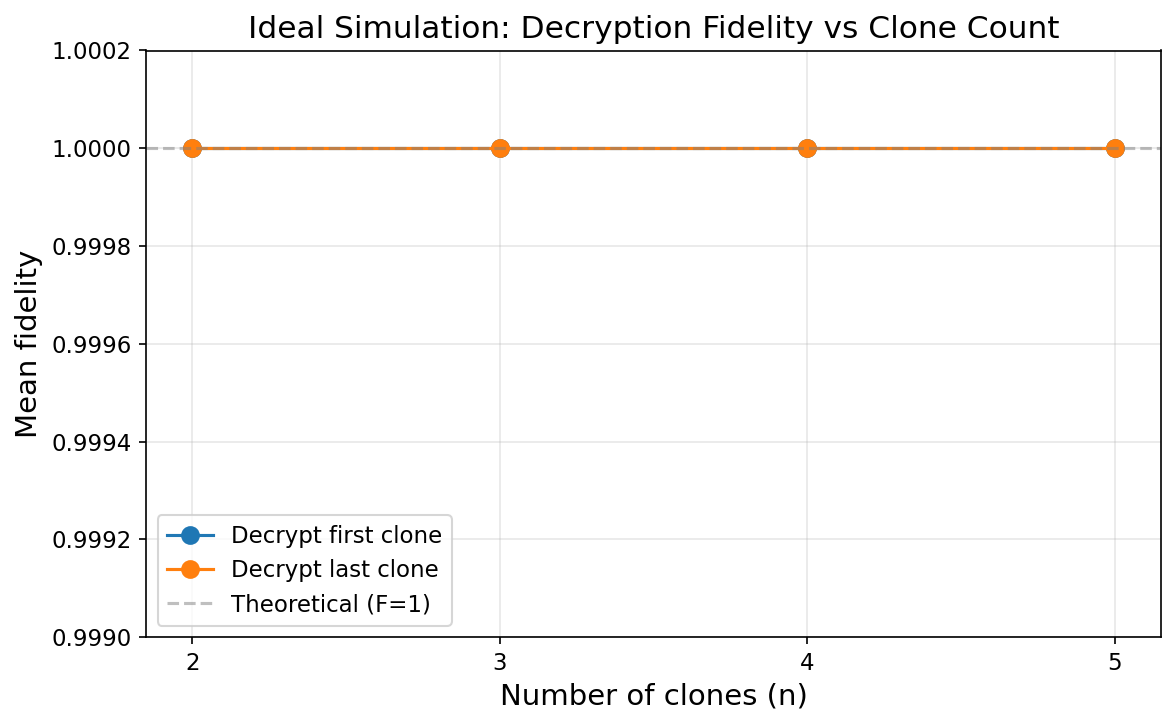

In [15]:
# Group by n and decrypt_mode
ns = sorted(set(r['n_clones'] for r in ideal))
modes = sorted(set(r['decrypt_mode'] for r in ideal))

fig, ax = plt.subplots(figsize=(8, 5))

for mode in modes:
    means = []
    max_devs = []
    for n in ns:
        fids = [r['fidelity'] for r in ideal
                if r['n_clones'] == n and r['decrypt_mode'] == mode]
        means.append(np.mean(fids))
        max_devs.append(max(abs(f - 1.0) for f in fids))
    
    label = f'Decrypt {mode} clone'
    ax.plot(ns, means, 'o-', label=label, markersize=8)

ax.set_xlabel('Number of clones (n)')
ax.set_ylabel('Mean fidelity')
ax.set_title('Ideal Simulation: Decryption Fidelity vs Clone Count')
ax.set_ylim(0.9990, 1.0002)
ax.axhline(y=1.0, color='grey', linestyle='--', alpha=0.5, label='Theoretical (F=1)')
ax.set_xticks(ns)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/ideal_fidelity_vs_n.png')
plt.show()

## Figure 2: Ideal Fidelity — Max Deviation from 1.0
Shows floating-point precision scaling with circuit size.

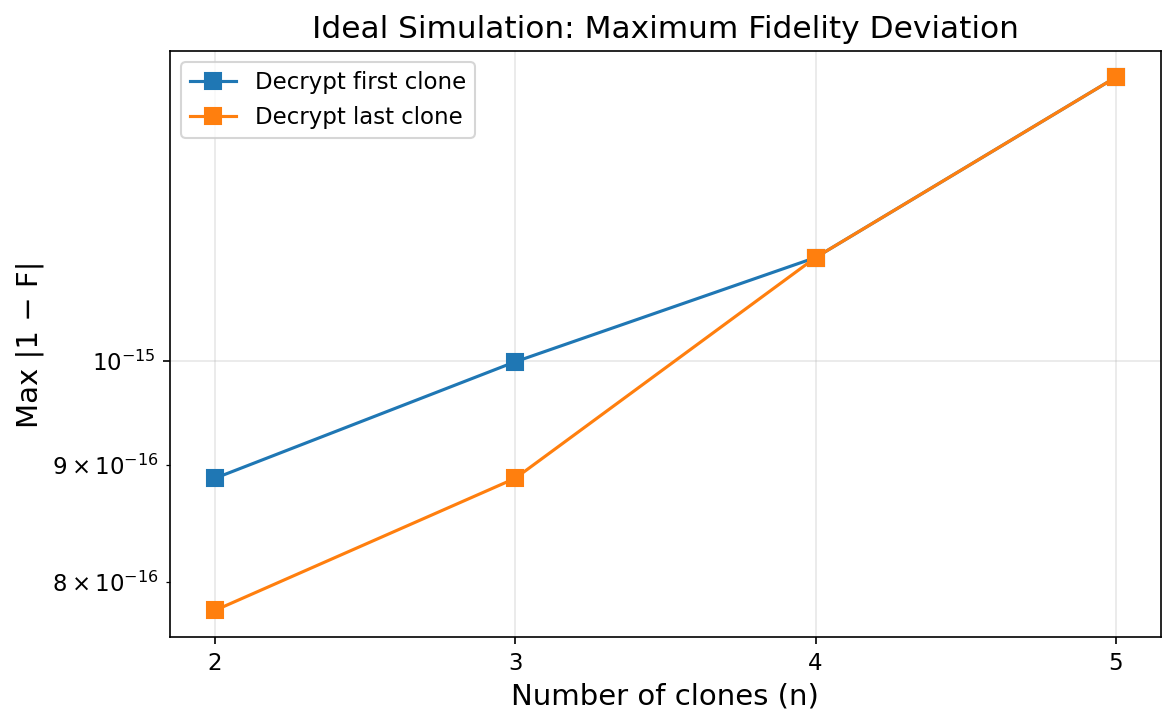

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

for mode in modes:
    max_devs = []
    for n in ns:
        fids = [r['fidelity'] for r in ideal
                if r['n_clones'] == n and r['decrypt_mode'] == mode]
        max_devs.append(max(abs(f - 1.0) for f in fids))
    
    ax.plot(ns, max_devs, 's-', label=f'Decrypt {mode} clone', markersize=8)

ax.set_xlabel('Number of clones (n)')
ax.set_ylabel('Max |1 − F|')
ax.set_title('Ideal Simulation: Maximum Fidelity Deviation')
ax.set_yscale('log')
ax.set_xticks(ns)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/ideal_max_deviation_vs_n.png')
plt.show()

## Figure 3: Noisy Fidelity vs Number of Clones (Heron R2 noise model)
Shows fidelity degradation under depolarising noise calibrated to IBM Heron R2.

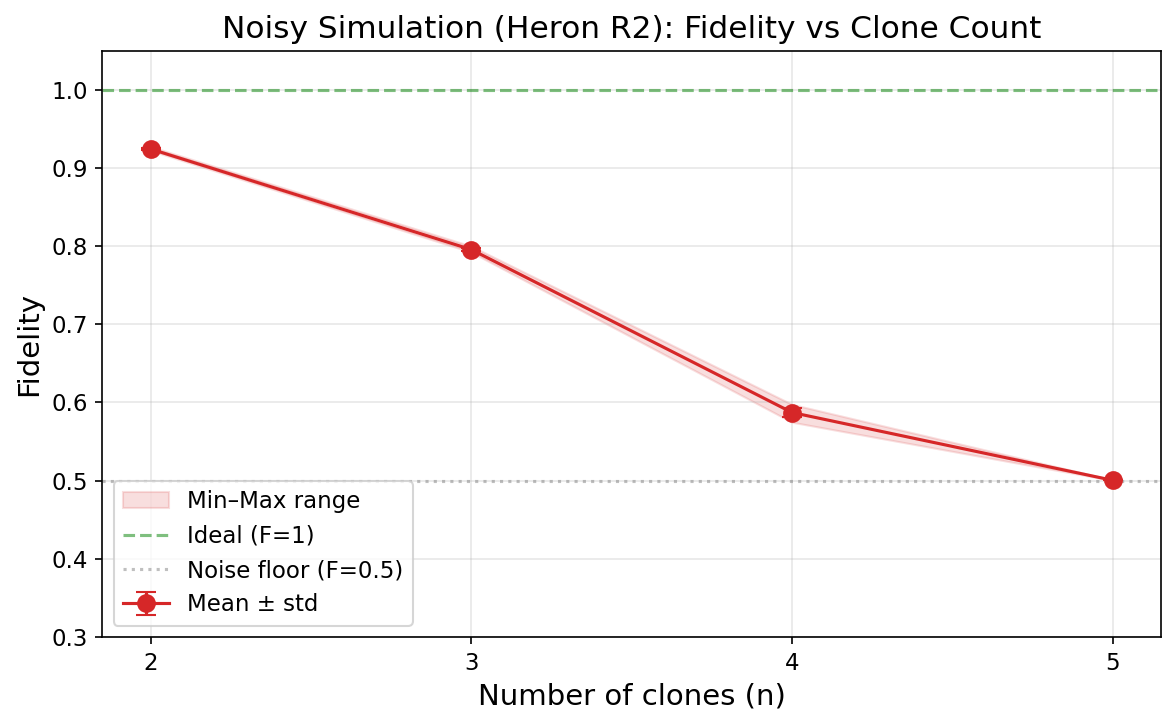

In [17]:
if noisy:
    ns_noisy = sorted(set(r['n_clones'] for r in noisy))
    
    means = []
    stds = []
    mins = []
    maxs = []
    for n in ns_noisy:
        fids = [r['fidelity'] for r in noisy if r['n_clones'] == n]
        means.append(np.mean(fids))
        stds.append(np.std(fids))
        mins.append(np.min(fids))
        maxs.append(np.max(fids))
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.errorbar(ns_noisy, means, yerr=stds, fmt='o-', capsize=5,
                color='#d62728', label='Mean ± std', markersize=8)
    ax.fill_between(ns_noisy, mins, maxs, alpha=0.15, color='#d62728',
                    label='Min–Max range')
    
    ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.5,
               label='Ideal (F=1)')
    ax.axhline(y=0.5, color='grey', linestyle=':', alpha=0.5,
               label='Noise floor (F=0.5)')
    
    ax.set_xlabel('Number of clones (n)')
    ax.set_ylabel('Fidelity')
    ax.set_title('Noisy Simulation (Heron R2): Fidelity vs Clone Count')
    ax.set_xticks(ns_noisy)
    ax.set_ylim(0.3, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/noisy_fidelity_vs_n.png')
    plt.show()
else:
    print('No noisy results found.')

## Figure 4: Ideal vs Noisy Fidelity Comparison
Side-by-side comparison showing the gap between theoretical and noisy performance.

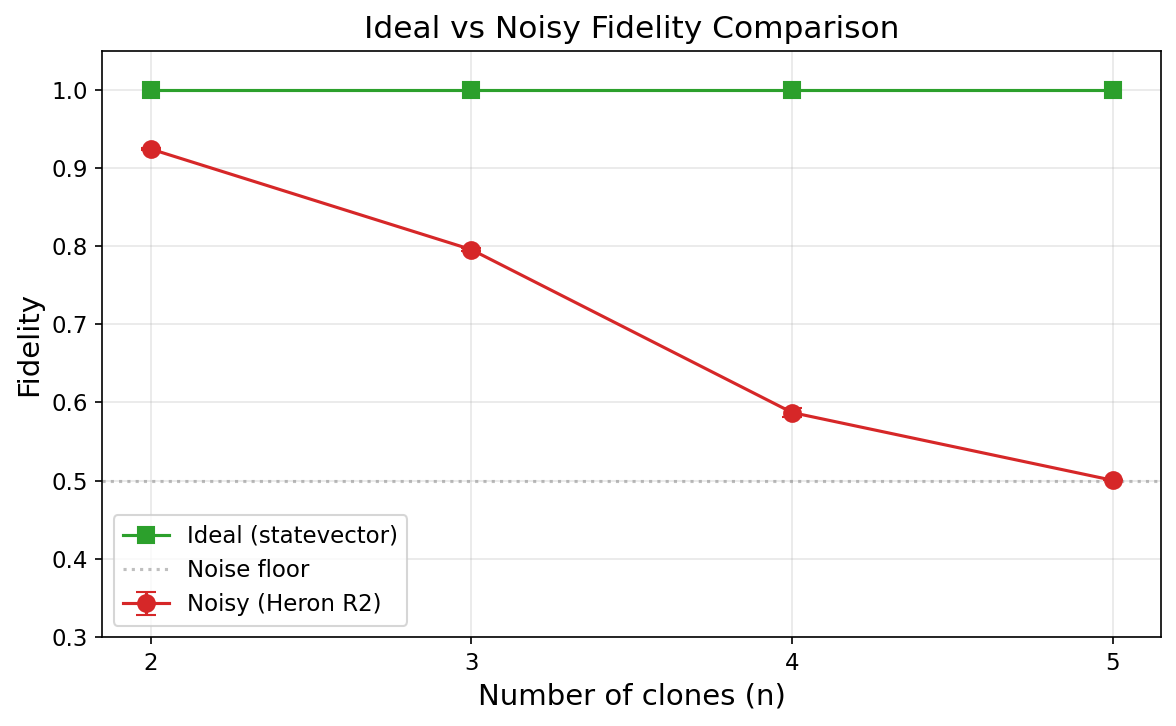

In [18]:
if noisy:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Ideal (first clone)
    ideal_means = []
    for n in ns:
        fids = [r['fidelity'] for r in ideal
                if r['n_clones'] == n and r['decrypt_mode'] == 'first']
        ideal_means.append(np.mean(fids))
    
    ax.plot(ns, ideal_means, 's-', color='#2ca02c', label='Ideal (statevector)',
            markersize=8)
    
    # Noisy
    noisy_means = []
    noisy_stds = []
    for n in ns_noisy:
        fids = [r['fidelity'] for r in noisy if r['n_clones'] == n]
        noisy_means.append(np.mean(fids))
        noisy_stds.append(np.std(fids))
    
    ax.errorbar(ns_noisy, noisy_means, yerr=noisy_stds, fmt='o-',
                capsize=5, color='#d62728', label='Noisy (Heron R2)',
                markersize=8)
    
    ax.axhline(y=0.5, color='grey', linestyle=':', alpha=0.5,
               label='Noise floor')
    
    ax.set_xlabel('Number of clones (n)')
    ax.set_ylabel('Fidelity')
    ax.set_title('Ideal vs Noisy Fidelity Comparison')
    ax.set_xticks(ns)
    ax.set_ylim(0.3, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/ideal_vs_noisy_fidelity.png')
    plt.show()
else:
    print('No noisy results found.')

## Figure 5: Fidelity Distribution (Box Plot per n)
Shows the spread of fidelity values across random input states.

/var/folders/n1/sg7h_ykd3979zm0fkg2x8tx00000gn/T/ipykernel_6686/3521672415.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,


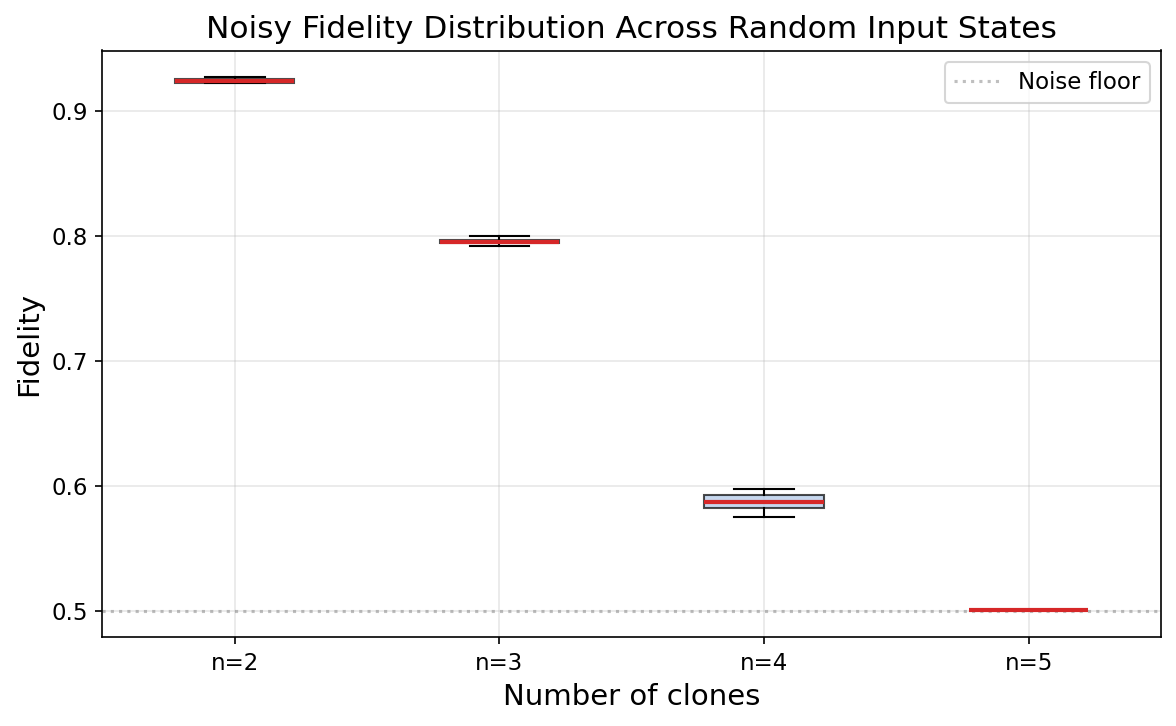

In [19]:
if noisy:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    box_data = []
    box_labels = []
    for n in ns_noisy:
        fids = [r['fidelity'] for r in noisy if r['n_clones'] == n]
        box_data.append(fids)
        box_labels.append(f'n={n}')
    
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                    boxprops=dict(facecolor='#aec7e8', alpha=0.7),
                    medianprops=dict(color='#d62728', linewidth=2))
    
    ax.axhline(y=0.5, color='grey', linestyle=':', alpha=0.5,
               label='Noise floor')
    
    ax.set_xlabel('Number of clones')
    ax.set_ylabel('Fidelity')
    ax.set_title('Noisy Fidelity Distribution Across Random Input States')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/noisy_fidelity_boxplot.png')
    plt.show()
else:
    print('No noisy results found.')

## Figure 6: Simulation Time vs Number of Clones
Shows how wall-clock simulation time scales with circuit size.

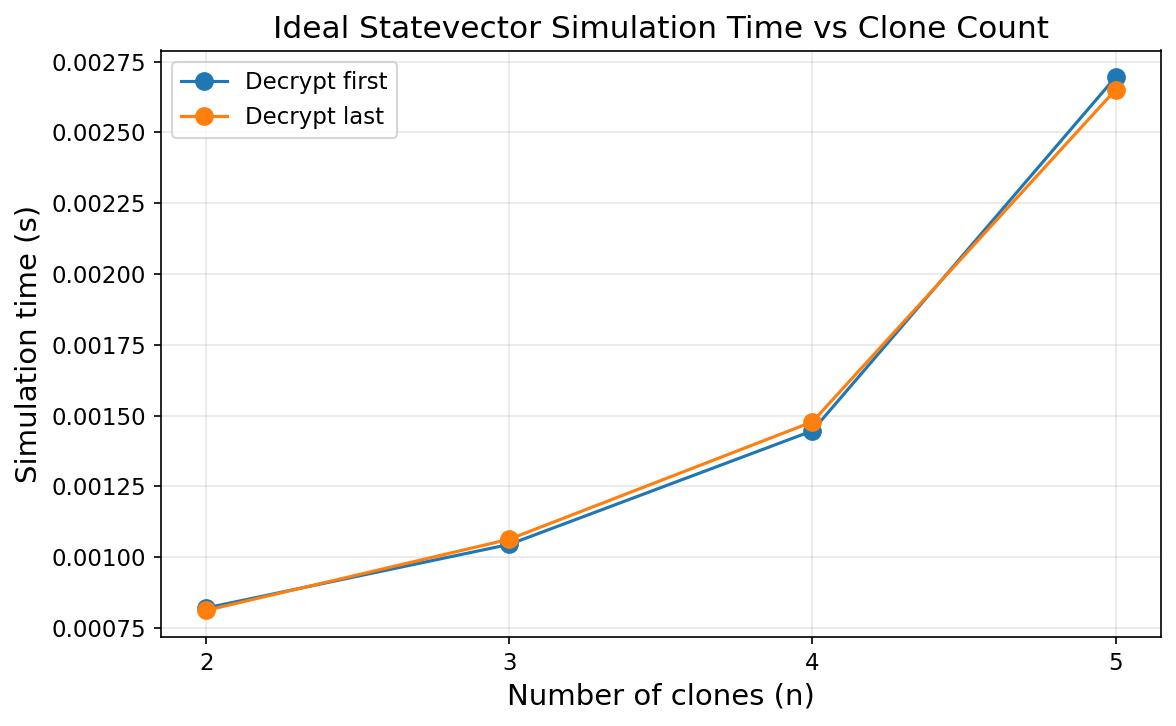

In [20]:
# Ideal simulation time
fig, ax = plt.subplots(figsize=(8, 5))

for mode in modes:
    sim_means = []
    for n in ns:
        times = [r['sim_time_s'] for r in ideal
                 if r['n_clones'] == n and r['decrypt_mode'] == mode]
        sim_means.append(np.mean(times))
    
    ax.plot(ns, sim_means, 'o-', label=f'Decrypt {mode}', markersize=8)

ax.set_xlabel('Number of clones (n)')
ax.set_ylabel('Simulation time (s)')
ax.set_title('Ideal Statevector Simulation Time vs Clone Count')
ax.set_xticks(ns)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/ideal_sim_time_vs_n.png')
plt.show()

## Figure 7: Noisy Simulation Time vs Number of Clones

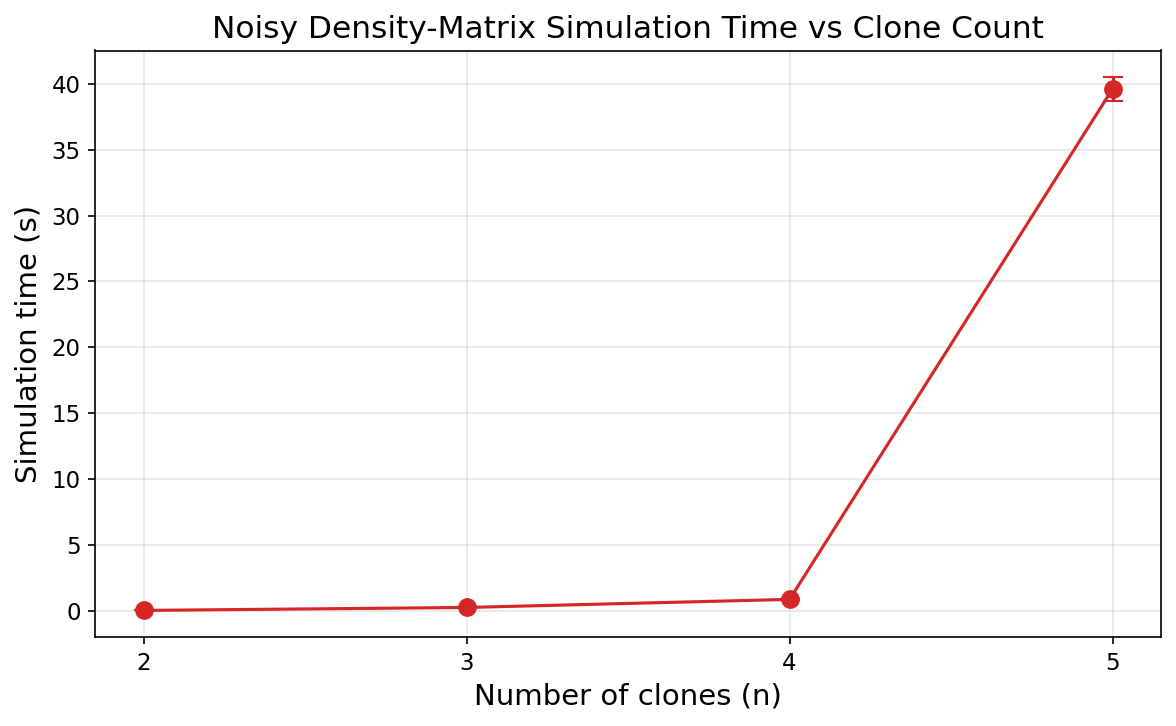

In [21]:
if noisy:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    sim_means = []
    sim_stds = []
    for n in ns_noisy:
        times = [r['sim_time_s'] for r in noisy if r['n_clones'] == n]
        sim_means.append(np.mean(times))
        sim_stds.append(np.std(times))
    
    ax.errorbar(ns_noisy, sim_means, yerr=sim_stds, fmt='o-',
                capsize=5, color='#d62728', markersize=8)
    
    ax.set_xlabel('Number of clones (n)')
    ax.set_ylabel('Simulation time (s)')
    ax.set_title('Noisy Density-Matrix Simulation Time vs Clone Count')
    ax.set_xticks(ns_noisy)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/noisy_sim_time_vs_n.png')
    plt.show()
else:
    print('No noisy results found.')

## Summary Table
Publication-ready table for the paper.

In [22]:
print('='*70)
print('IDEAL FIDELITY SUMMARY')
print('='*70)
print(f'{"n":>4}  {"Trials":>6}  {"Mean F":>14}  {"Min F":>14}  {"Max |1-F|":>12}')
print('-'*60)
for row in ideal_summary:
    print(f"{row['n_clones']:>4}  {row['trials']:>6}  "
          f"{row['mean_fidelity']:>14.12f}  {row['min_fidelity']:>14.12f}  "
          f"{row['max_deviation']:>12.2e}")

if noisy_summary:
    print()
    print('='*70)
    print('NOISY FIDELITY SUMMARY (Heron R2: 1q=1e-4, 2q=5e-3)')
    print('='*70)
    print(f'{"n":>4}  {"Trials":>6}  {"Mean F":>10}  {"Std":>10}  '
          f'{"Min F":>10}  {"Max F":>10}')
    print('-'*60)
    for row in noisy_summary:
        print(f"{row['n_clones']:>4}  {row['trials']:>6}  "
              f"{row['mean_fidelity']:>10.6f}  {row['std_fidelity']:>10.6f}  "
              f"{row['min_fidelity']:>10.6f}  {row['max_fidelity']:>10.6f}")

IDEAL FIDELITY SUMMARY
   n  Trials          Mean F           Min F     Max |1-F|
------------------------------------------------------------
   2     200  1.000000000000  1.000000000000      8.88e-16
   3     200  1.000000000000  1.000000000000      9.99e-16
   4     200  1.000000000000  1.000000000000      1.11e-15
   5     200  1.000000000000  1.000000000000      1.33e-15

NOISY FIDELITY SUMMARY (Heron R2: 1q=1e-4, 2q=5e-3)
   n  Trials      Mean F         Std       Min F       Max F
------------------------------------------------------------
   2     100    0.924110    0.001576    0.922145    0.927157
   3     100    0.795442    0.001949    0.792105    0.799876
   4     100    0.587107    0.006322    0.574711    0.597520
   5     100    0.500412    0.000145    0.500234    0.500747
